In [1]:
import os
import pickle
from pennylane import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import pennylane as qml
import numpy as np

import pandas as pd
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import time
import copy
from collections import Counter
import math


## Configuration

In [2]:
DATA_PATH = "dataset/mirage2019_LOPEZ_lopez_lopez_36P_4F_APP_xST_PAD_metadata.pickle"
BATCH_SIZE = 50
EPOCHS = 100
LEARNING_RATE = 1e-3
ENABLE_EARLY_STOPPING = False
PATIENCE = 15 # Early stopping patience
RANDOM_SEED = 2025

N_PACKETS = 10 # max 36
N_FEATURES = 4

N_QUBITS = 5
N_LAYERS = 3

# Riproducibilità
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED) # Utile per hash di dizionari/set

# 2. PyTorch (CPU e GPU)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# 3. Determinismo su GPU (CuDNN)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device('cpu')  # Force CPU for testing
print(f"Using device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti


## Load Data

In [3]:
print("Loading dataset...")
with open(DATA_PATH, "rb") as f:
    X_raw = np.array(pickle.load(f), dtype=np.float32) # Convert to numpy array
    y_raw = np.array(pickle.load(f)) # Convert to numpy array

print(f"Data shape: {X_raw.shape}")
print(f"Labels shape: {len(y_raw)}")

# Example sample
example_sample = 5000
print("\nExample Sample (First 5 packets):\n", X_raw[example_sample][:5])
print("Example Label:", y_raw[example_sample])

Loading dataset...
Data shape: (96999, 36, 4)
Labels shape: 96999

Example Sample (First 5 packets):
 [[0.00e+00 2.31e+02 3.43e+02 0.00e+00]
 [1.00e+00 1.52e+02 4.40e+02 0.00e+00]
 [0.00e+00 5.10e+01 3.47e+02 0.00e+00]
 [0.00e+00 1.46e+03 3.47e+02 0.00e+00]
 [0.00e+00 3.87e+02 3.47e+02 0.00e+00]]
Example Label: AccuWeather


## Label Encoding

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print("Classes:", le.classes_)

Number of classes: 40
Classes: ['8 Ball Pool' 'AccuWeather' 'Amazon' 'Booking' 'Comics' 'Diretta'
 'Dropbox' 'Duolingo' 'Facebook' 'Flipboard' 'FourSquare' 'Google Drive'
 'Groupon' 'Hangouts' 'Instagram' 'Linkedin' 'Messenger' 'Musixmatch'
 'OneDrive' 'OneFootball' 'Pinterest' 'Playstore' 'Reddit' 'Skype'
 'Slither.io' 'SoundCloud' 'Spotify' 'Subito' 'Telegram' 'Trello'
 'TripAdvisor' 'Tumblr' 'Twitter' 'Uber' 'Viber' 'Waze' 'Wish' 'Youtube'
 'eBay' 'ilMeteo']


## Train-Validation-Test split

In [5]:
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# Check if sizes sum to 1
assert TRAIN_SIZE + VAL_SIZE + TEST_SIZE == 1.0, "Train, Val, Test sizes must sum to 1."

# First split: 85% Train+Val, 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y_encoded, test_size=TEST_SIZE, stratify=y_encoded, random_state=2025)

# Second split: Split the 85% into Train (70% total) and Val (15% total)
# 15 / 85 ~= 0.1765
tmp_size = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=tmp_size, stratify=y_temp, random_state=2025)

# # For testing resize training to 1000 samples
# X_train = X_train[:1000]
# y_train = y_train[:1000]
# X_val = X_val[:500]
# y_val = y_val[:500]
# X_test = X_test[:500]
# y_test = y_test[:500]

print(f"Train shape: {X_train.shape} ({len(X_train)/len(X_raw):.1%})")
print(f"Val shape:   {X_val.shape}   ({len(X_val)/len(X_raw):.1%})")
print(f"Test shape:  {X_test.shape}  ({len(X_test)/len(X_raw):.1%})")

Train shape: (67899, 36, 4) (70.0%)
Val shape:   (14550, 36, 4)   (15.0%)
Test shape:  (14550, 36, 4)  (15.0%)


(Optional) Reduce Training set size

In [ ]:
# New training size
NEW_TRAIN_SIZE = 30000
if len(X_train) > NEW_TRAIN_SIZE:
    percentage = NEW_TRAIN_SIZE / len(X_train)
    # train test spit to reduce training set size
    X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=percentage, stratify=y_train, random_state=2025)
    print(f"Reduced Train shape: {X_train.shape} ({len(X_train)/len(X_raw):.1%})")
else:
    print("Training set size is less than or equal to the new size. No reduction applied.")

## Preprocessing Strategy 1

This domain-aware approach explicitly masks padding values to ensure they do not corrupt the model's learning process. It utilizes Log1p normalization to compress the dynamic range of heavy-tailed network features effectively mitigating the impact of outliers while preserving the semantic distinction between padding and actual data.

In [6]:
def preprocess_data(X):
    """
    Handles padding and normalizes features.
    X shape: (N, 36, 4)
    Features: [DIR, PL, TCPWIN, IAT]
    """
    X_proc = X.copy().astype(np.float32)
    
    # Mask for padding (using PL at index 1)
    is_padding = (X_proc[:, :, 1] == -1)
    
    # Set all features to 0 where is_padding is True
    mask = np.repeat(is_padding[:, :, np.newaxis], 4, axis=2)
    X_proc[mask] = 0
    
    # Apply Log1p to PL (1), TCPWIN (2), IAT (3)
    X_proc[:, :, 1:] = np.log1p(np.maximum(X_proc[:, :, 1:], 0)) 
    
    return X_proc[:, :N_PACKETS, :]

print("Preprocessing data...")
X_train_proc = preprocess_data(X_train)
X_val_proc = preprocess_data(X_val)
X_test_proc = preprocess_data(X_test)

print("Preprocessing complete.")
print("Train shape:", X_train_proc.shape)
print("Val shape:", X_val_proc.shape)
print("Test shape:", X_test_proc.shape)

Preprocessing data...
Preprocessing complete.
Train shape: (67899, 10, 4)
Val shape: (14550, 10, 4)
Test shape: (14550, 10, 4)


## Preprocessing Strategy 2

This generic method employs a standard Min-Max Scaler to linearly map all feature values into a fixed [0, 1] range without special handling for padding. Consequently, it is highly sensitive to outliers, which can cause valid traffic data to be compressed into an indistinguishably small interval, while also incorrectly treating padding markers as valid minimum values.

In [ ]:
def preprocess_data(X):
    X_proc = X.copy().astype(np.float32)
    # min max scaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(np.reshape(X_proc, [-1, N_FEATURES]))
    X_proc = scaler.transform(np.reshape(X_proc, [-1, N_FEATURES]))
    X_proc = np.reshape(X_proc, [-1, X.shape[1], N_FEATURES])
    return X_proc[:, :N_PACKETS, :]

print("Preprocessing data...")
X_train_proc = preprocess_data(X_train)
X_val_proc = preprocess_data(X_val)
X_test_proc = preprocess_data(X_test)

print("Preprocessing complete.")
print("Train shape:", X_train_proc.shape)
print("Val shape:", X_val_proc.shape)
print("Test shape:", X_test_proc.shape)

## Preprocessing Strategy 3

This approach prioritizes feature engineering by merging direction and size into a single "signed throughput" feature, effectively reducing dimensionality while capturing flow dynamics. However, by subsequently applying a standard Min-Max Scaler without explicit padding masking, it obscures the semantic zero-point of the signed data and remains vulnerable to outlier compression.

In [ ]:
# Combined DIR and PL into signed PL
def combine_dir_pl(input_array):
    # Extract columns based on their role
    control_column = input_array[:, :, 0] # DIR
    data_values = input_array[:, :, 1] # PL

    # Determine the multiplier: -1 if control_column is 1, 1 otherwise
    sign_multiplier = np.where(control_column == 1, -1, 1)

    # Apply the sign correction to the data values
    signed_data_values = data_values * sign_multiplier

    # Extract the remaining features
    other_features = input_array[:, :, 2:4]

    # Reshape the processed column to maintain 3D structure for concatenation
    signed_data_values_reshaped = signed_data_values[:, :, np.newaxis]

    # Concatenate the processed column with the other features
    processed_array = np.concatenate((signed_data_values_reshaped, other_features), axis=2)
    return processed_array

In [ ]:

def preprocess_data(X):
    """
    Combines DIR and PL into signed PL, handles padding, and normalizes features.
    X shape: (N, 36, 4)
    Features: [DIR, PL, TCPWIN, IAT]
    """
    X_proc = X.copy().astype(np.float32)
    # Combine DIR and PL into signed PL
    X_proc = combine_dir_pl(X_proc)
    # min max scaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    # Now features are: [signed_PL, TCPWIN, IAT]
    N_FEATURES = 3
    scaler.fit(np.reshape(X_proc, [-1, N_FEATURES]))
    X_proc = scaler.transform(np.reshape(X_proc, [-1, N_FEATURES]))
    X_proc = np.reshape(X_proc, [-1, X.shape[1], N_FEATURES])
    return X_proc[:, :N_PACKETS, :]


print("Preprocessing data...")
X_train_proc = preprocess_data(X_train)
X_val_proc = preprocess_data(X_val)
X_test_proc = preprocess_data(X_test)

print("Preprocessing complete.")
print("Train shape:", X_train_proc.shape)
print("Val shape:", X_val_proc.shape)
print("Test shape:", X_test_proc.shape)

# Adjust N_FEATURES accordingly
N_FEATURES = 3
print("Adjusted N_FEATURES:", N_FEATURES)


## Preprocessing Strategy 4

combines the domain-aware padding handling and Log1p normalization of Strategy 1 with the feature engineering of Strategy 3. By merging direction and size into a signed throughput feature while explicitly masking padding values, it effectively reduces dimensionality and preserves semantic integrity, enhancing the model's ability to learn meaningful patterns from the data.

In [ ]:
def preprocess_data(X):
    """
    Handles padding and normalizes features.
    X shape: (N, 36, 4)
    Features: [DIR, PL, TCPWIN, IAT]
    """
    X_proc = X.copy().astype(np.float32)
    # Mask for padding (using PL at index 1)
    is_padding = (X_proc[:, :, 1] == -1)

    # Set all features to 0 where is_padding is True
    mask = np.repeat(is_padding[:, :, np.newaxis], 4, axis=2)
    X_proc[mask] = 0

    # Apply Log1p to PL (1), TCPWIN (2), IAT (3)
    X_proc[:, :, 1:] = np.log1p(np.maximum(X_proc[:, :, 1:], 0))
    X_proc = combine_dir_pl(X_proc)
    return X_proc[:, :N_PACKETS, :]

print("Preprocessing data...")
X_train_proc = preprocess_data(X_train)
X_val_proc = preprocess_data(X_val)
X_test_proc = preprocess_data(X_test)

print("Preprocessing complete.")
print("Train shape:", X_train_proc.shape)
print("Val shape:", X_val_proc.shape)
print("Test shape:", X_test_proc.shape)

# Adjust N_FEATURES accordingly
N_FEATURES = 3
print("Adjusted N_FEATURES:", N_FEATURES)

## Dataset & Dataloader
Pytorch Dataset wrapper.

In [7]:
class MirageDataset(Dataset):
    def __init__(self, X, y):
        # X shape: (N, 36, 4)
        # CNN 1D expects (N, Channels, Length) -> (N, 4, 36)
        self.X = torch.FloatTensor(X).permute(0, 2, 1).double().to(DEVICE) # Remove to(DEVICE) if dataset doesn't fit in memory
        self.y = torch.LongTensor(y).to(DEVICE) # Remove to(DEVICE) if dataset doesn't fit in memory

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MirageDataset(X_train_proc, y_train)
val_dataset = MirageDataset(X_val_proc, y_val)
test_dataset = MirageDataset(X_test_proc, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## Model Selection

### Amplitude Embedding Model
A hybrid neural network that leverages Amplitude Embedding to encode classical data into the amplitudes of the quantum state. This approach maximizes data density, allowing the encoding of $2^N$ features into $N$ qubits, preceded by a sigmoid-activated classical dense layer.

In [18]:
from nn_models import AmpHybridModel as HybridModel

### Angle Embedding Model
A streamlined hybrid model utilizing Angle Embedding, where input features are mapped directly to qubit rotation angles in a 1:1 ratio. It features a classical pre-processing layer followed by a quantum circuit with strongly entangling layers, offering a shallow and noise-resilient embedding strategy.

In [ ]:
from nn_models import AngleHybridModel as HybridModel

### Ring Model
A hybrid architecture that employs a custom Ring Embedding strategy, splitting the input into two sets of features encoded via rotations and circular CNOT entangling patterns. This design doubles the data capacity compared to simple angle embedding and introduces correlations between qubits early in the circuit.

In [ ]:
from nn_models import RingHybridModel as HybridModel

### Waterfall Model
A complex hybrid model featuring a Waterfall Embedding scheme that splits inputs into Y-rotation and Z-rotation blocks. It incorporates a dense, all-to-all "waterfall" connectivity of CNOT gates in the first stage, creating a highly entangled state before the variational ansatz layers.

In [ ]:
from nn_models import WaterfallHybridModel as HybridModel

### Classical 1D CNN Model

In [39]:
from nn_models import TrafficCNN as HybridModel

### Esperimento


In [22]:
class AmpCnn(nn.Module):
    def __init__(self, n_qubits, n_layers, n_packets, n_features, num_classes, random_seed=42):
        super(AmpCnn, self).__init__()

        # Parametri
        self.n_qubits = n_qubits
        self.q_output_dim = 2**n_qubits  # Dimensione output quantistico (es. 2^5 = 32)
        self.n_layers = n_layers
        self.n_packets = n_packets
        self.n_features = n_features
        self.num_classes = num_classes

        # Configurazione Pennylane
        self.dev = qml.device("default.qubit", wires=n_qubits, seed=random_seed)

        @qml.qnode(self.dev, interface="torch")
        def qnode(inputs, weights):
            qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True, pad_with=0.0)
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            return qml.probs(wires=range(n_qubits))

        weight_shapes = {"weights": (n_layers, n_qubits, 3)}

        # --- ARCHITETTURA ---

        # 1. Pre-processing Classico
        self.flatten_in = nn.Flatten()
        self.dense_pre = nn.Linear(n_packets * n_features, self.q_output_dim)
        self.activation_pre = nn.Sigmoid()

        # 2. Quantum Layer
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)

        # 3. Strati Convoluzionali 1D (Aggiunti)
        # Input shape per Conv1d: (Batch, Channels, Length) -> (Batch, 1, 2^n_qubits)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2) # Riduce la lunghezza della sequenza a metà

        # 4. Strati Densi Finali (Aggiunti)
        # Calcolo della dimensione dopo convoluzioni e pooling:
        # La lunghezza cala da 2^n_qubits a (2^n_qubits / 2) a causa del MaxPool1d
        self.flatten_conv = nn.Flatten()
        flattened_size = 32 * (self.q_output_dim // 2)

        self.fc1 = nn.Linear(flattened_size, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input -> Dense -> Quantum
        x = self.flatten_in(x)
        x = self.dense_pre(x)
        x = self.activation_pre(x)
        x = self.q_layer(x)

        # Reshape per Conv1d: (Batch, 1, 2^n_qubits)
        x = x.view(-1, 1, self.q_output_dim)

        # Fase Convoluzionale 1D
        x = self.relu1(self.conv1(x))
        x = self.pool(self.relu2(self.conv2(x)))

        # Fase Densa
        x = self.flatten_conv(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)

        return x

    def get_model_name(self):
        """
        Restituisce una stringa con il nome del modello che riassume i parametri principali.

        Returns:
            str: Nome del modello nel formato "AmpHybrid_Qn_Ln_PxF_Cc"
                 dove n=n_qubits, n=n_layers, P=n_packets, F=n_features, C=num_classes
        """
        return f"AmpHybrid_CUSTOM_Q{self.n_qubits}_L{self.n_layers}_{self.n_packets}x{self.n_features}_C{self.num_classes}"

    def get_model_name_short(self):
        """
        Restituisce una stringa con il nome breve del modello.

        Returns:
            str: Nome breve del modello nel formato "AmpHybrid_Qn_Ln"
                 dove n=n_qubits, n=n_layers
        """
        return f"AmpHybrid_CUSTOM_Q{self.n_qubits}_L{self.n_layers}"

HybridModel = AmpCnn

In [12]:
class ClassicalTwinModel(nn.Module):
    def __init__(self, n_qubits, n_layers, n_packets, n_features, num_classes, random_seed=42):
        super(ClassicalTwinModel, self).__init__()

        self.n_qubits = n_qubits
        self.q_output_dim = 2**n_qubits  # Dimensione output quantistico (es. 2^5 = 32)
        self.n_layers = n_layers
        self.n_packets = n_packets
        self.n_features = n_features
        self.num_classes = num_classes

        # --- ARCHITETTURA ---

        # 1. Pre-processing (Uguale all'originale)
        self.flatten_in = nn.Flatten()
        self.dense_pre = nn.Linear(n_packets * n_features, self.q_output_dim)
        self.activation_pre = nn.Sigmoid()

        # 2. Strato che sostituisce il Quantum Layer
        # Usiamo un Linear che mappa 2^n_qubits in 2^n_qubits
        # Questo sostituisce il lavoro dei gate quantistici
        self.classical_replacement = nn.Linear(self.q_output_dim, self.q_output_dim)
        self.activation_replacement = nn.ReLU() # o Sigmoid per simulare meglio i limiti del quantum

        # 3. Strati Convoluzionali 1D (Uguali all'originale)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)

        # 4. Strati Densi Finali (Uguali all'originale)
        self.flatten_conv = nn.Flatten()
        flattened_size = 32 * (self.q_output_dim // 2)

        self.fc1 = nn.Linear(flattened_size, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input -> Dense -> Sostituto Classico
        x = self.flatten_in(x)
        x = self.dense_pre(x)
        x = self.activation_pre(x)

        # Qui bypassiamo il quantum layer e usiamo il sostituto classico
        x = self.classical_replacement(x)
        x = self.activation_replacement(x)

        # Reshape per Conv1d
        x = x.view(-1, 1, self.q_output_dim)

        # Fase Convoluzionale 1D
        x = self.relu1(self.conv1(x))
        x = self.pool(self.relu2(self.conv2(x)))

        # Fase Densa
        x = self.flatten_conv(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)

        return x

    def get_model_name(self):
        return f"AmpHybrid_CUSTOMTWIN_Q{self.n_qubits}_L{self.n_layers}_{self.n_packets}x{self.n_features}_C{self.num_classes}"

    def get_model_name_short(self):
        return f"AmpHybrid_CUSTOMTWIN_Q{self.n_qubits}_L{self.n_layers}"

HybridModel = ClassicalTwinModel

In [14]:
class ClassicalLight(nn.Module):
    def __init__(self, n_qubits, n_layers, n_packets, n_features, num_classes, random_seed=42):
        super(ClassicalLight, self).__init__()

        # Parametri
        self.n_qubits = n_qubits
        self.q_output_dim = 2**n_qubits  # Dimensione output quantistico (es. 2^5 = 32)
        self.n_layers = n_layers
        self.n_packets = n_packets
        self.n_features = n_features
        self.num_classes = num_classes
        self.latent_dim = self.q_output_dim

        # --- ARCHITETTURA ---

        # 1. Pre-processing Classico
        self.flatten_in = nn.Flatten()
        self.dense_pre = nn.Linear(n_packets * n_features, self.latent_dim)
        self.activation_pre = nn.Sigmoid()
        # self.activation_pre = nn.ReLU()

        # 2. Strati Convoluzionali 1D
        # Input shape per Conv1d: (Batch, Channels, Length) -> (Batch, 1, latent_dim)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)

        # 3. Strati Densi Finali
        # Calcolo della dimensione dopo il MaxPool1d (lunghezza dimezzata)
        self.flatten_conv = nn.Flatten()
        flattened_size = 32 * (self.latent_dim // 2)

        self.fc1 = nn.Linear(flattened_size, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Input -> Dense (sostituisce il blocco Quantum)
        x = self.flatten_in(x)
        x = self.dense_pre(x)
        x = self.activation_pre(x)

        # Reshape per Conv1d: (Batch, Channels, Length)
        x = x.view(-1, 1, self.latent_dim)

        # Fase Convoluzionale 1D
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.pool(x)

        # Fase Densa
        x = self.flatten_conv(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)

        return x

    def get_model_name(self):
        return f"AmpHybrid_CUSTOMLIGHT_Q{self.n_qubits}_L{self.n_layers}_{self.n_packets}x{self.n_features}_C{self.num_classes}"

    def get_model_name_short(self):
        return f"AmpHybrid_CUSTOMLIGHT_Q{self.n_qubits}_L{self.n_layers}"

HybridModel = ClassicalLight

In [30]:
class CnnAmpCnn(nn.Module):
    def __init__(self, n_qubits, n_layers, n_packets, n_features, num_classes, random_seed=42):
        super(CnnAmpCnn, self).__init__()

        # Parametri
        self.n_qubits = n_qubits
        self.q_input_dim = 2**n_qubits  # Dimensione necessaria per AmplitudeEmbedding
        self.n_layers = n_layers
        self.n_packets = n_packets
        self.n_features = n_features
        self.num_classes = num_classes

        # --- 1. PRIMA CNN (Input -> CNN1D) ---
        # Input shape: (Batch, n_features, n_packets)
        self.cnn1_pre = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten()
        )

        # Calcolo dimensione dopo cnn1 per collegarla al Quantum Layer
        # Assumendo MaxPool riduca a metà la lunghezza (n_packets // 2)
        cnn1_out_features = 16 * (n_packets // 2)

        # Layer di adattamento per AmplitudeEmbedding (deve essere di dimensione 2^n_qubits)
        self.pre_quantum_dense = nn.Linear(cnn1_out_features, self.q_input_dim)
        self.pre_quantum_act = nn.Sigmoid()

        # --- 2. QUANTUM LAYER ---
        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def qnode(inputs, weights):
            # L'input qui deve avere dimensione 2^n_qubits
            qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True, pad_with=0.0)
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            return qml.probs(wires=range(n_qubits))

        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(qnode, weight_shapes)

        # --- 3. SECONDA CNN (Quantum -> CNN1D) ---
        # L'output quantistico è (Batch, 2^n_qubits), lo trasformiamo in (Batch, 1, 2^n_qubits)
        self.cnn2_post = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten()
        )

        # --- 4. DENSE LAYERS (CNN1D -> Dense -> Dense) ---
        # Dimensione dopo la seconda CNN e il pooling: 32 canali * (2^n_qubits / 2)
        cnn2_out_features = 32 * (self.q_input_dim // 2)

        self.fc1 = nn.Linear(cnn2_out_features, 64)
        self.relu_fc = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # 1. CNN1D iniziale
        # x shape: (Batch, n_packets, n_features) -> serve (Batch, n_features, n_packets)
        # x = x.transpose(1, 2)
        x = self.cnn1_pre(x)

        # Adattamento per il Quantum Layer
        x = self.pre_quantum_dense(x)
        x = self.pre_quantum_act(x)

        # 2. Quantum Layer
        x = self.quantum_layer(x) # Output shape: (Batch, 2^n_qubits)

        # 3. CNN1D secondaria
        # Reshape per Conv1d: (Batch, 1, Seq_Length)
        x = x.view(-1, 1, self.q_input_dim)
        x = self.cnn2_post(x)

        # 4. Dense Layers finali
        x = self.relu_fc(self.fc1(x))
        x = self.fc2(x)

        return x

    def get_model_name(self):
        return f"CnnAmpCnn_Q{self.n_qubits}_L{self.n_layers}_{self.n_packets}x{self.n_features}_C{self.num_classes}"

    def get_model_name_short(self):
        return f"CnnAmpCnn_Q{self.n_qubits}_L{self.n_layers}"

HybridModel = CnnAmpCnn

In [20]:
class Dense(nn.Module):
    def __init__(self, n_qubits, n_layers, n_packets, n_features, num_classes, random_seed=42):
        super(Dense, self).__init__()

        # Salva i parametri come attributi
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.n_packets = n_packets
        self.n_features = n_features
        self.num_classes = num_classes
        self.random_seed = random_seed

        # 1. Flatten
        # Input shape originale: (n_packets, n_features)
        # Dimensione appiattita: n_packets * n_features
        self.flatten = nn.Flatten()

        # 2. Dense Layer (Pre-processing per il quantum layer)
        # Output dim deve essere 2^n_qubits per l'AmplitudeEmbedding
        input_dim = n_packets * n_features
        self.dense1 = nn.Linear(input_dim, 2**n_qubits)
        # self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

        # 3. Quantum Layer
        # Sostituisce qml.qnn.KerasLayer
        # self.q_layer = nn.Linear(2**n_qubits, 2**n_qubits)  # Placeholder per il quantum layer

        # 4. Output Dense Layer
        # Input dim è 2^n_qubits (output di qml.probs)
        self.dense2 = nn.Linear(2**n_qubits, num_classes)
        # self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.relu(x)
        # x = self.q_layer(x)
        return self.dense2(x)
        # return self.softmax(x)

    def get_model_name(self):
        return f"Dense"

    def get_model_name_short(self):
        return f"Dense"
HybridModel = Dense

Model instantiation

In [40]:
model = HybridModel(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    n_features=N_FEATURES,
    n_packets=N_PACKETS,
    num_classes=NUM_CLASSES
)
# Sposta il modello sul device e convertilo in double (float64) per precisione quantistica
model = model.to(DEVICE).double()
print(model.get_model_name())
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Totale parametri addestrabili: {total_params:,}")

TrafficCNN_C40
TrafficCNN(
  (features): Sequential(
    (0): Conv1d(4, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=40, bias=True)
  )
)
Totale parametri addestrabili: 163,048


## Training Setup

In [23]:
# Configurazione Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        # inputs, labels = inputs.to(DEVICE), labels.to(DEVICE) # Remove comment if dataset does't fit into memory

        optimizer.zero_grad()
        outputs = model(inputs)
        # loss = criterion(torch.log(outputs + 1e-10), labels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # scheduler.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            # inputs, labels = inputs.to(DEVICE), labels.to(DEVICE) # Remove comment if dataset does't fit into memory
            outputs = model(inputs)
            # loss = criterion(torch.log(outputs + 1e-10), labels)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

### CrossEntropy Loss function

The cross-entropy loss (or log loss) is a fundamental metric in classification models, measuring the difference between the predicted probability distribution and the true distribution of the labels. It heavily penalizes predictions that are confidently wrong, guiding the model to improve its predictions by minimizing this difference during training.

In [24]:
criterion = nn.CrossEntropyLoss()

### Wieghted CrossEntropy Loss function

Weighted CrossEntropy assigns different weights to each class based on their frequency in the training set. Classes with fewer samples receive higher weights, helping the model to pay more attention to them during training.

In [20]:
def compute_class_weights():
    class_counts = Counter(y_train)
    total_samples = sum(class_counts.values())
    weights = []
    for i in range(NUM_CLASSES):
        count = class_counts.get(i, 0)
        if count > 0:
            weights.append(total_samples / (NUM_CLASSES * count))
        else:
            weights.append(1.0)
    return torch.FloatTensor(weights)

In [21]:
class_weights = compute_class_weights().to(DEVICE).double()
criterion = nn.CrossEntropyLoss(weight=class_weights)

### Focal Loss function

Focal loss is designed to address class imbalance by down-weighting easy examples and focusing more on hard, misclassified examples. Weights are calculated in the same way as Weighted CrossEntropy. Gamma is a tunable focusing parameter that adjusts the rate at which easy examples are down-weighted.

In [ ]:
GAMMA = 2.0 # Focusing parameter. 2 is a common choice.
ALPHA = compute_class_weights().to(DEVICE).double()

Another strategy. Gamma is set to 3.0 to increase the focus on hard examples and ALPHA is set to uniform weights.

In [28]:
GAMMA = 3.0
ALPHA = torch.ones(NUM_CLASSES, dtype=torch.double).to(DEVICE)

In [29]:

# Loading Focal loss from torch hub
focal_loss = torch.hub.load(
	'adeelh/pytorch-multi-class-focal-loss',
	model='focal_loss',
	alpha=ALPHA,
	gamma=GAMMA,
	reduction='mean',
	device=DEVICE,
	dtype=torch.double,
	force_reload=False
)

criterion = focal_loss

Using cache found in C:\Users\Matte/.cache\torch\hub\adeelh_pytorch-multi-class-focal-loss_master


## Training Loop

In [37]:
# Dizionario per salvare la history
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

In [38]:
print(f"[INFO] Addestramento iniziato. {model.get_model_name()}")
start_time = time.time()

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0

EPOCHS = 50
PATIENCE = 10
ENABLE_EARLY_STOPPING = True

for epoch in range(EPOCHS):
    start_epoch_time = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    end_epoch_time = time.time()
    epoch_duration = end_epoch_time - start_epoch_time

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Loss: {train_loss:.4f} - Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}"
          f" | Time: {epoch_duration:.2f}s")


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> Validation loss improved. Model saved.")
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience: {patience_counter}", f"/ {PATIENCE}" if ENABLE_EARLY_STOPPING else "")

    if patience_counter >= PATIENCE and ENABLE_EARLY_STOPPING:
        print("Early stopping triggered.")
        break

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes.")

# Load best model weights
last_model = copy.deepcopy(model)
model.load_state_dict(best_model_wts)

[INFO] Addestramento iniziato. Dense
Epoch 1/50 | Loss: 2.9477 - Acc: 22.4746 | Val Loss: 2.6773 - Val Acc: 28.7216 | Time: 1.83s
  -> Validation loss improved. Model saved.
Epoch 2/50 | Loss: 2.5688 - Acc: 31.8650 | Val Loss: 2.4775 - Val Acc: 34.5567 | Time: 1.73s
  -> Validation loss improved. Model saved.
Epoch 3/50 | Loss: 2.4212 - Acc: 36.4365 | Val Loss: 2.3667 - Val Acc: 37.4089 | Time: 1.55s
  -> Validation loss improved. Model saved.
Epoch 4/50 | Loss: 2.3331 - Acc: 39.1051 | Val Loss: 2.2948 - Val Acc: 40.7491 | Time: 1.69s
  -> Validation loss improved. Model saved.
Epoch 5/50 | Loss: 2.2683 - Acc: 40.9387 | Val Loss: 2.2282 - Val Acc: 41.9931 | Time: 1.68s
  -> Validation loss improved. Model saved.
Epoch 6/50 | Loss: 2.2177 - Acc: 42.2893 | Val Loss: 2.2013 - Val Acc: 42.5979 | Time: 1.63s
  -> Validation loss improved. Model saved.
Epoch 7/50 | Loss: 2.1785 - Acc: 43.2672 | Val Loss: 2.1549 - Val Acc: 44.3986 | Time: 1.56s
  -> Validation loss improved. Model saved.
Epoc

<All keys matched successfully>

Saving Results

In [29]:
# Saving results
model_name = "50E_log1p_Dense"
output_dir = "./cross_AMPcnn_quantum_models"

os.makedirs(f"{output_dir}", exist_ok=True)
os.makedirs(f"{output_dir}/{model_name}", exist_ok=True)

# with open(f"{output_dir}/{model_name}/model_summary.txt", "w") as f:
#     model.summary(print_fn=lambda x: f.write(x + "\n"))

df_history = pd.DataFrame(history)
df_history.to_csv(f"{output_dir}/{model_name}/training_history.csv", index=False)

torch.save(model.state_dict(), f"{output_dir}/{model_name}/model.pth")

## Testing and Evaluation

(Optnional) Load Model

In [34]:
output_dir = "./cross_AMPcnn_quantum_models"
model_name = "50E_log1p_CnnAmpCnn"

model = HybridModel(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    n_features=N_FEATURES,
    n_packets=N_PACKETS,
    num_classes=NUM_CLASSES
)
model = model.double()
weights = torch.load(f"{output_dir}/{model_name}/model.pth", map_location=DEVICE)
load_result = model.load_state_dict(weights)
print(f"Esito caricamento: {load_result}")
model = model.to(DEVICE)
model.eval()
print('Model loaded correctly')


# Load training history from csv
df_history = pd.read_csv(f"{output_dir}/{model_name}/training_history.csv")
history = df_history.to_dict(orient='list')


Esito caricamento: <All keys matched successfully>
Model loaded correctly


Testing set loss and accuracy

In [14]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Test Loss: 1.9022 | Test Acc: 49.24%


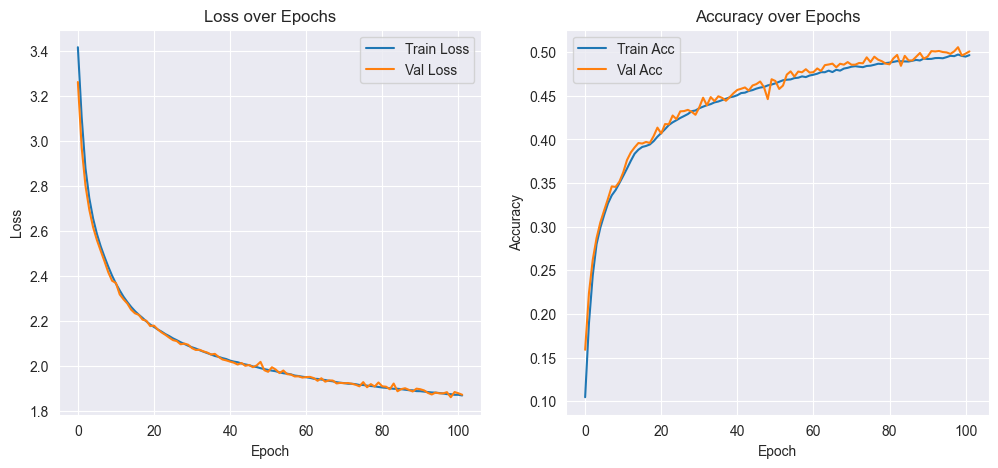

In [15]:
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']
epochs_range = range(len(acc))

training_validation_plots = plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [30]:
# salva plot su file
training_validation_plots.savefig(f"{output_dir}/{model_name}/training_validation_plots.png")

In [35]:
# Confusion Matrix
# Confusion Matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy()) # Replace with all_labels.extend(labels.numpy()) if using CPU

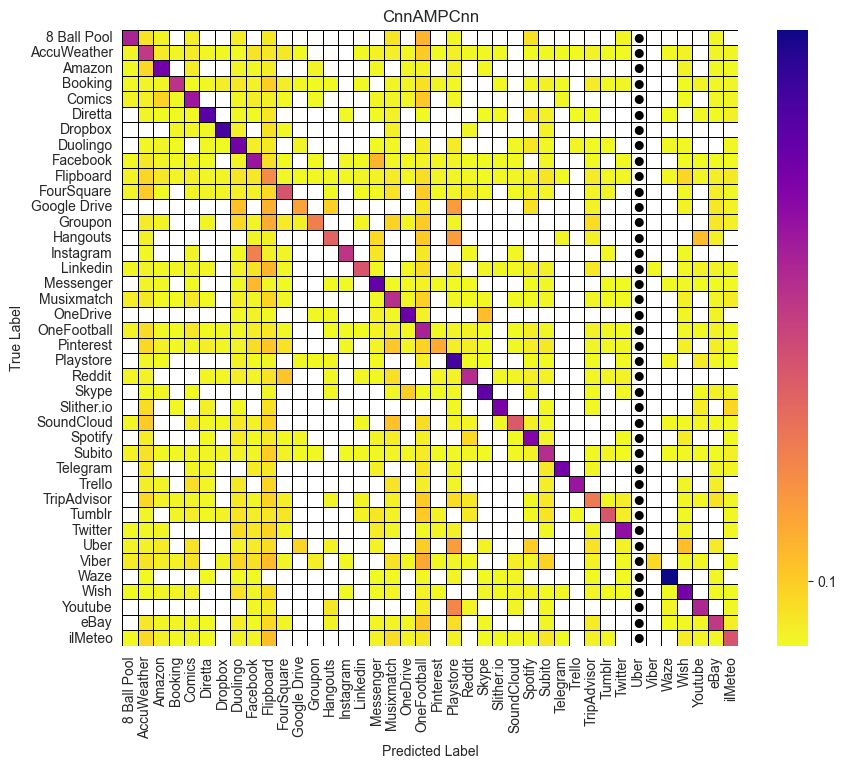

In [37]:
cm = confusion_matrix(all_labels, all_preds, normalize='true')
confusion_matrix_plot = plt.figure(figsize=(10, 8))


mask = cm == 0
ax =sns.heatmap(
    cm,
    annot=False,
    fmt='',
    cmap='plasma_r',                 # Mappa colori simile (plasma invertita)
    linewidths=0.5,                  # Spessore linee della griglia
    mask=mask,                       # Applica la maschera
    linecolor='black',               # Colore linee della griglia
    square=True,                     # Celle quadrate
    cbar_kws={"ticks": [0.1, 1, 10, 100]}, xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_facecolor('white')

empty_cols = np.where(cm.sum(axis=0) == 0)[0]

for col in empty_cols:
    for row in range(cm.shape[0]):
        # col + 0.5 e row + 0.5 servono a centrare il testo nella cella
        ax.text(col + 0.5, row + 0.5, '●',
                ha='center', va='center',
                color='black', fontsize=15)


plt.title("CnnAMPCnn")
# plt.title("AMP 68k")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [38]:
# salva plot su file
confusion_matrix_plot.savefig(f"{output_dir}/{model_name}/confusion_matrix.png")

In [28]:
# --- 3. Classification Report ---
print("Classification Report:")
report_dict = classification_report(all_labels, all_preds, target_names=le.classes_, labels=np.arange(40), digits=4, zero_division=0)
print(report_dict)

Classification Report:
              precision    recall  f1-score   support

 8 Ball Pool     0.5049    0.5365    0.5202       192
 AccuWeather     0.4382    0.4621    0.4499       898
      Amazon     0.3230    0.6912    0.4403       272
     Booking     0.5570    0.4612    0.5046       477
      Comics     0.4192    0.5303    0.4682       396
     Diretta     0.7882    0.7486    0.7679       537
     Dropbox     0.7661    0.7198    0.7422       182
    Duolingo     0.4199    0.5388    0.4720       399
    Facebook     0.5198    0.5603    0.5393      1244
   Flipboard     0.1829    0.2204    0.1999       776
  FourSquare     0.4892    0.3266    0.3917       346
Google Drive     0.3333    0.1296    0.1867        54
     Groupon     0.4898    0.2474    0.3288        97
    Hangouts     0.3000    0.0583    0.0976       103
   Instagram     0.6824    0.4265    0.5249       136
    Linkedin     0.6790    0.3107    0.4264       177
   Messenger     0.6813    0.7278    0.7038      1216
  Mu

In [32]:
# Salva classification report su file
with open(f"{output_dir}/{model_name}/classification_report.txt", "w") as f:
    f.write(report_dict)
